# 16.C21A/18.C21A Problem Set #2 — Solutions
Due Wednesday 15 April 2026

In [11]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'font.size': 11})

## Problem 1: Fourier Stability of Multi-Step and Multi-Stage Methods (5+5+10)

The power of Fourier analysis is that it reduces the stability of a PDE discretization to: (1) find $\lambda_m \Delta t$ as a function of $\beta_m = k_m \Delta x$ for the spatial scheme, and (2) check that $\lambda_m \Delta t$ lies inside the stability region of the time integrator for all $\beta_m \in [-\pi, \pi]$.

In this problem we fix the spatial discretization and ask: *how does the choice of time integrator change the allowable CFL?*

**1a)** Amplification factors by hand (5 pts)

Consider the first-order upwind spatial discretization of the 1D convection equation ($\mu = 0$, $u > 0$):

$$\frac{dU_j}{dt} = -\frac{u}{\Delta x}(U_j - U_{j-1}).$$

The Fourier eigenvalues are $\lambda_m = -\frac{u}{\Delta x}(1 - e^{-i\beta_m})$.

For each of the following time integrators, derive the **amplification factor** $g(\beta_m) \equiv \hat{U}_m^{n+1}/\hat{U}_m^n$:

1. **Forward Euler**: $U^{n+1} = U^n + \Delta t \, f(U^n)$
2. **Leapfrog** (second-order centered in time): $U^{n+1} = U^{n-1} + 2\Delta t \, f(U^n)$
3. **RK2 (Heun's method)**: $U^* = U^n + \Delta t\,f(U^n)$, $\;U^{n+1} = U^n + \frac{\Delta t}{2}[f(U^n) + f(U^*)]$

For Leapfrog, note that $g$ satisfies a *quadratic* equation — find both roots and discuss which is the "physical" mode and which is the "computational" (parasitic) mode.

### Solution Problem 1(a)

After Fourier decomposition, each mode $m$ satisfies the scalar ODE $d\hat{U}_m/dt = \lambda_m \hat{U}_m$ with eigenvalue $\lambda_m = -(u/\Delta x)(1 - e^{-i\beta_m})$. The amplification factor $g(\beta_m) = \hat{U}_m^{n+1}/\hat{U}_m^n$ depends on the time integrator. We write $z_m = \lambda_m \Delta t = -\nu(1 - e^{-i\beta_m})$ where $\nu = u\Delta t/\Delta x$, and drop the subscript $m$ below for brevity.

**1. Forward Euler.** $\hat{U}_m^{n+1} = \hat{U}_m^n + \Delta t\,\lambda_m \hat{U}_m^n = (1 + z)\,\hat{U}_m^n$, so

$$g_{\text{FE}} = 1 + z = 1 - \nu(1 - e^{-i\beta_m}).$$

**2. Leapfrog.** $\hat{U}_m^{n+1} = \hat{U}_m^{n-1} + 2\Delta t\,\lambda_m \hat{U}_m^n$. Substituting $\hat{U}_m^n = g^n \hat{U}_m^0$:

$$g^{n+1} = g^{n-1} + 2z\,g^n \;\;\Longrightarrow\;\; g^2 - 2zg - 1 = 0.$$

By the quadratic formula: $g^{\pm} = z \pm \sqrt{z^2+1}.$

**Physical vs parasitic mode.** The exact solution of $d\hat{U}_m/dt = \lambda_m \hat{U}_m$ over one timestep is $\hat{U}_m(t+\Delta t) = e^{\lambda_m\Delta t}\hat{U}_m(t)$, so the exact amplification factor is $g_{\text{exact}} = e^z$. A consistent numerical root must recover this as $\Delta t \to 0$ (i.e., $z \to 0$), meaning $g \to e^z \to 1$.

Evaluating the two roots in this limit: $g^+ = z + \sqrt{z^2+1} \to +1$ and $g^- = z - \sqrt{z^2+1} \to -1$. Therefore $g^+$ is the **physical** mode (consistent with $e^z$), while $g^-$ is the **parasitic** (computational) mode — it flips sign every timestep, which has no continuous analog.

Why two roots? Leapfrog couples two time levels ($\hat{U}_m^{n+1}$ and $\hat{U}_m^{n-1}$), making the characteristic equation quadratic. But the PDE is first-order in time, so only one root should approximate $e^z$. The second is an artifact of the method's extra memory. In general, a $k$-step method has $k$ roots; only one is physical, and the remaining $k-1$ parasitic roots must satisfy $|g| \le 1$ for stability (the root condition).

**3. RK2 (Heun).** Working in the $m$-th mode: Stage 1 gives $\hat{U}_m^* = (1+z)\,\hat{U}_m^n$. Stage 2:

$$\hat{U}_m^{n+1} = \hat{U}_m^n + \frac{\Delta t}{2}\bigl[\lambda_m \hat{U}_m^n + \lambda_m \hat{U}_m^*\bigr] = \hat{U}_m^n\!\left(1 + \frac{z}{2}[1 + (1+z)]\right) = \left(1 + z + \frac{z^2}{2}\right)\hat{U}_m^n.$$

Hence $g_{\text{RK2}} = 1 + z + z^2/2$, the degree-2 Taylor polynomial of $e^z$, as expected for a second-order method.

**1b)** The $|g| \leq 1$ contour and maximum CFL (5 pts)

1. For **Forward Euler + upwind**, show analytically that $|g|^2 = 1 - 2\nu(1 - \nu)(1 - \cos\beta_m)$, and hence $|g| \leq 1$ iff $0 \leq \nu \leq 1$.
2. For **Leapfrog + upwind**, show that the physical root satisfies $|g| \leq 1$ for $\nu \leq 1$, but the parasitic root satisfies $|g| > 1$ for *any* $\nu > 0$ at $\beta_m = \pi$. Conclude: Leapfrog + upwind is **unconditionally unstable**.
3. For **RK2 + upwind**, determine the maximum stable CFL numerically.

### Solution Problem 1(b)

**1. FE + upwind.**

With $z = -\nu(1-\cos\beta) - i\nu\sin\beta$, we have $g = 1+z$, so

$$|g|^2 = (1-\nu+\nu\cos\beta)^2 + \nu^2\sin^2\beta = 1 - 2\nu(1-\nu)(1-\cos\beta).$$

Since $1-\cos\beta \ge 0$, stability $|g|\le 1$ requires $\nu(1-\nu)\ge 0$, i.e., $0\le\nu\le 1$. $\checkmark$

**2. Leapfrog + upwind is unconditionally unstable.**

By Vieta's formula, $g^+g^- = -1$, hence $|g^+|\cdot|g^-| = 1$.

At $\beta=\pi$: $z=-2\nu$ (real), giving $g^+ = -2\nu + \sqrt{4\nu^2+1}$. Then $g^+ \le 1$ iff $\sqrt{4\nu^2+1}\le 1+2\nu$, which squares to $0\le 4\nu$ — true, with equality only at $\nu=0$. So $|g^+|<1$ for $\nu>0$, forcing $|g^-|>1$. The parasitic mode grows at every $\beta=\pi$, so **Leapfrog + upwind is unconditionally unstable**. Since $g^-<-1$, this manifests as sawtooth oscillations.

**3. RK2 + upwind:** bisection over $\nu$ (code below) gives $\nu_{\max}^{\text{RK2}} \approx 1.0$.

In [12]:
# RK2 + upwind: find max stable CFL numerically
beta = np.linspace(0, 2*np.pi, 10000)

def max_g_rk2(nu):
    z = -nu * (1 - np.exp(-1j * beta))
    g = 1 + z + z**2 / 2
    return np.max(np.abs(g))

# Bisection
nu_lo, nu_hi = 0.5, 2.0
for _ in range(60):
    nu_mid = (nu_lo + nu_hi) / 2
    if max_g_rk2(nu_mid) <= 1.0 + 1e-14:
        nu_lo = nu_mid
    else:
        nu_hi = nu_mid

print(f"RK2 + upwind: max stable CFL = {nu_lo:.6f}")

# Also verify FE stability region
def max_g_fe(nu):
    z = -nu * (1 - np.exp(-1j * beta))
    return np.max(np.abs(1 + z))

print(f"FE + upwind at CFL=1.0: max|g| = {max_g_fe(1.0):.6f}")
print(f"FE + upwind at CFL=1.01: max|g| = {max_g_fe(1.01):.6f}")

RK2 + upwind: max stable CFL = 1.000000
FE + upwind at CFL=1.0: max|g| = 1.000000
FE + upwind at CFL=1.01: max|g| = 1.020000


**1c)** Numerical verification — the pulse test (5 pts)

Solve 1D convection ($u = 1$, periodic domain $[0, 1]$, $N_x = 200$) with upwind spatial differencing and each time integrator. Use $U_0(x) = e^{-300(x - 0.5)^2}$.

1. For FE and RK2, run at CFL = 0.8 to $t = 1$. Plot final solutions vs exact. Compute $L^2$ error.
2. Run Leapfrog at CFL = 0.8 — show the blow-up.
3. Compare FE at CFL = 0.5 vs 0.95: dissipation vs dispersion trade-off.

### Solution Problem 1(c)

  Leapfrog blew up at step 43/250, max|U| = 2.64e+06


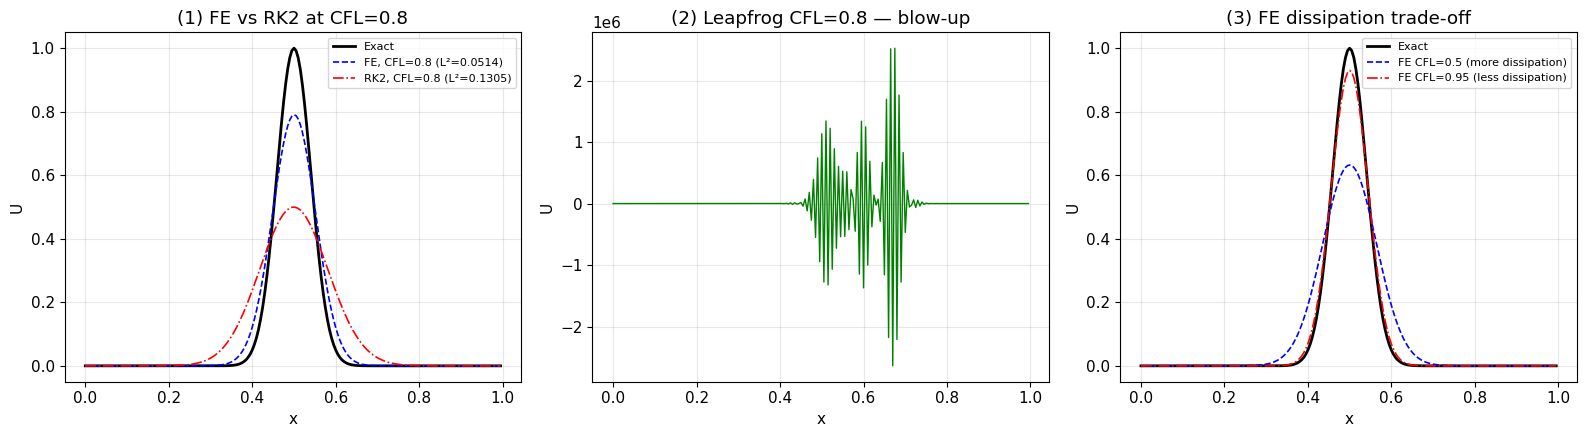

L² errors: FE@0.8=5.1384e-02, RK2@0.8=1.3051e-01


In [13]:
# ── Problem 1(c): Pulse test ──
u = 1.0;  Nx = 200;  xL, xR = 0.0, 1.0
x = np.linspace(xL, xR, Nx, endpoint=False)
dx = (xR - xL) / Nx
U0 = np.exp(-300 * (x - 0.5)**2)

def upwind_rhs(U, u, dx):
    """dU/dt = -(u/dx)(U_j - U_{j-1}), periodic."""
    return -(u / dx) * (U - np.roll(U, 1))

def run_fe(U0, u, dx, CFL, t_final):
    dt = CFL * dx / u
    Nt = int(np.round(t_final / dt))
    dt = t_final / Nt  # adjust for exact t_final
    U = U0.copy()
    for _ in range(Nt):
        U = U + dt * upwind_rhs(U, u, dx)
    return U

def run_leapfrog(U0, u, dx, CFL, t_final, Nt_max=None):
    dt = CFL * dx / u
    Nt = int(np.round(t_final / dt)) if Nt_max is None else Nt_max
    dt = t_final / Nt
    U_prev = U0.copy()
    U_curr = U_prev + dt * upwind_rhs(U_prev, u, dx)  # bootstrap with FE
    for n in range(1, Nt):
        U_next = U_prev + 2 * dt * upwind_rhs(U_curr, u, dx)
        U_prev = U_curr
        U_curr = U_next
        if np.max(np.abs(U_curr)) > 1e6:
            print(f"  Leapfrog blew up at step {n+1}/{Nt}, max|U| = {np.max(np.abs(U_curr)):.2e}")
            return U_curr
    return U_curr

def run_rk2(U0, u, dx, CFL, t_final):
    dt = CFL * dx / u
    Nt = int(np.round(t_final / dt))
    dt = t_final / Nt
    U = U0.copy()
    for _ in range(Nt):
        k1 = upwind_rhs(U, u, dx)
        k2 = upwind_rhs(U + dt * k1, u, dx)
        U = U + (dt / 2) * (k1 + k2)
    return U

t_final = 1.0  # one full period on [0,1] → exact = U0

# (1) FE and RK2 at CFL = 0.8
U_fe  = run_fe(U0, u, dx, 0.8, t_final)
U_rk2 = run_rk2(U0, u, dx, 0.8, t_final)
err_fe  = np.sqrt(dx * np.sum((U_fe  - U0)**2))
err_rk2 = np.sqrt(dx * np.sum((U_rk2 - U0)**2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(x, U0, 'k-', lw=2, label='Exact')
ax.plot(x, U_fe, 'b--', lw=1.2, label=f'FE, CFL=0.8 (L²={err_fe:.4f})')
ax.plot(x, U_rk2, 'r-.', lw=1.2, label=f'RK2, CFL=0.8 (L²={err_rk2:.4f})')
ax.set_title('(1) FE vs RK2 at CFL=0.8');  ax.legend(fontsize=8)
ax.set_xlabel('x');  ax.set_ylabel('U');  ax.grid(True, alpha=0.3)

# (2) Leapfrog blow-up
ax = axes[1]
U_lf = run_leapfrog(U0, u, dx, 0.8, t_final)
ax.plot(x, U_lf, 'g-', lw=1)
ax.set_title('(2) Leapfrog CFL=0.8 — blow-up')
ax.set_xlabel('x');  ax.set_ylabel('U');  ax.grid(True, alpha=0.3)

# (3) FE: CFL 0.5 vs 0.95
U_fe_05  = run_fe(U0, u, dx, 0.5,  t_final)
U_fe_095 = run_fe(U0, u, dx, 0.95, t_final)
ax = axes[2]
ax.plot(x, U0, 'k-', lw=2, label='Exact')
ax.plot(x, U_fe_05, 'b--', lw=1.2, label='FE CFL=0.5 (more dissipation)')
ax.plot(x, U_fe_095, 'r-.', lw=1.2, label='FE CFL=0.95 (less dissipation)')
ax.set_title('(3) FE dissipation trade-off');  ax.legend(fontsize=8)
ax.set_xlabel('x');  ax.set_ylabel('U');  ax.grid(True, alpha=0.3)

plt.tight_layout();  plt.show()
print(f"L² errors: FE@0.8={err_fe:.4e}, RK2@0.8={err_rk2:.4e}")

**Analysis.**
At CFL $= 0.8$, FE+upwind has dissipation factor $\nu(1-\nu) = 0.16$ — close to exact transport at $\nu=1$. RK2's amplification factor $|1+z+z^2/2|$ drops well below 1 at intermediate wavenumbers, making it *more* dissipative here. So **FE has the smaller $L^2$ error** at this CFL. Leapfrog confirms unconditional instability (sawtooth blow-up). Comparing CFL $= 0.5$ vs $0.95$ for FE: at $\nu=0.5$, heavy damping ($\nu(1-\nu)=0.25$); at $\nu=0.95$, minimal damping ($\nu(1-\nu)=0.0475$). The sweet spot is $\nu\to 1$ (exact transport).

## Problem 2: Dispersion, Phase Speed, and Group Velocity (5+10+10)

For the semi-discrete equation $d\mathbf{U}/dt = A\mathbf{U}$ with periodic BCs, Fourier analysis gives eigenvalues $\lambda_m$ parameterized by the reduced wavenumber $\beta_m = k_m\Delta x \in [-\pi, \pi]$. Each eigenvalue controls how the Fourier mode $e^{ik_m x}$ evolves in time: its imaginary part sets the oscillation frequency, and its real part sets the growth or decay rate.

The *phase speed* is the speed at which individual wave crests of a single Fourier mode travel:
$$c_{\text{phase}}(\beta) = -\frac{\operatorname{Im}(\lambda)}{k} = -\Delta x\,\frac{\operatorname{Im}(\lambda)}{\beta}.$$

The *group velocity* is the speed at which the envelope of a narrow-band wave packet (a cluster of modes near wavenumber $k$) travels. It is the derivative of frequency with respect to wavenumber:
$$c_{\text{group}}(\beta) = -\frac{d\,\operatorname{Im}(\lambda)}{dk} = -\Delta x\,\frac{d\,\operatorname{Im}(\lambda)}{d\beta}.$$

When $c_{\text{phase}}$ is the same for every $\beta$, all wavelengths travel at the same speed and any initial shape is transported without distortion: the scheme is *non-dispersive*. When $c_{\text{phase}}$ varies with $\beta$, different Fourier components of a signal separate over time, causing pulses to spread and develop oscillatory features. This is *numerical dispersion*.

Separately, $\operatorname{Re}(\lambda) = 0$ means mode amplitudes are preserved (no dissipation), while $\operatorname{Re}(\lambda) < 0$ means modes decay exponentially. This is *numerical dissipation*. A scheme can be dispersive, dissipative, both, or neither.

For the exact convection equation, $\lambda = -iuk$ gives $c_{\text{phase}} = c_{\text{group}} = u$ for all modes and $\operatorname{Re}(\lambda) = 0$: no dispersion and no dissipation. Any deviation from this is a purely numerical artifact.

**2a)** Analytical dispersion relations (5 pts)

For central differences applied to pure convection, the semi-discrete eigenvalue is:
$$\lambda_m^{\text{CD}} = -i\frac{u}{\Delta x}\sin\beta_m.$$

1. Suppose a numerical scheme has $c_{\text{phase}}$ that decreases with $\beta$ and $\operatorname{Re}(\lambda) = 0$ for all modes. A narrow Gaussian pulse containing many wavenumbers is propagated forward in time. Describe qualitatively what happens to the pulse over time. Does it maintain its shape, spread out, or decay? Which Fourier components (long or short wavelength) travel faster?

2. Derive $c_{\text{phase}}^{\text{CD}}(\beta)$ and $c_{\text{group}}^{\text{CD}}(\beta)$ from the definitions in the preamble. Show that
$$c_{\text{phase}}^{\text{CD}} = u\frac{\sin\beta}{\beta}, \qquad c_{\text{group}}^{\text{CD}} = u\cos\beta.$$

3. Evaluate $c_{\text{group}}^{\text{CD}}$ at $\beta = \pi/2$ and $\beta = \pi$. (The number of grid points per wavelength is $N_\lambda = 2\pi/\beta$, so these correspond to $N_\lambda = 4$ and $N_\lambda = 2$ respectively.) Interpret the sign of $c_{\text{group}}$ at $\beta = \pi$: in which direction does a wave packet centered at this wavenumber propagate, and why does this produce upstream oscillations in a rightward-traveling convection problem?

4. For the upwind scheme, $\lambda_m^{\text{UW}} = -(u/\Delta x)(1 - e^{-i\beta_m})$. Separate $\lambda^{\text{UW}}$ into real and imaginary parts. Show that $\operatorname{Im}(\lambda^{\text{UW}}) = \operatorname{Im}(\lambda^{\text{CD}})$, so both schemes share the same $c_{\text{phase}}$ and $c_{\text{group}}$. Then show that $\operatorname{Re}(\lambda^{\text{UW}}) = -(u/\Delta x)(1-\cos\beta) \le 0$. At which $\beta$ is this damping strongest? Explain why it is beneficial that the most damped modes are exactly those whose group velocity is most distorted.

### Solution Problem 2(a)

**1.** The pulse does not decay because $\operatorname{Re}(\lambda)=0$ preserves the amplitude of every Fourier mode. However, since $c_{\text{phase}}$ decreases with $\beta$, long-wavelength (small $\beta$) components travel near the correct speed $u$ while short-wavelength (large $\beta$) components lag behind. Over time, the fast low-frequency content pulls ahead and the slow high-frequency content trails behind, so the pulse spreads and develops oscillatory ripples on its trailing side. The total energy ($L^2$ norm) is conserved even though the shape distorts.

**2.** From $\lambda^{\text{CD}} = -i(u/\Delta x)\sin\beta$, we read off $\operatorname{Im}(\lambda) = -(u/\Delta x)\sin\beta$. Substituting into the definitions:

$$c_{\text{phase}} = -\Delta x\,\frac{\operatorname{Im}(\lambda)}{\beta} = u\,\frac{\sin\beta}{\beta}, \qquad c_{\text{group}} = -\Delta x\,\frac{d\,\operatorname{Im}(\lambda)}{d\beta} = u\cos\beta.$$

**3.** At $\beta = \pi/2$ ($N_\lambda = 4$): $c_{\text{group}} = 0$. The envelope of a wave packet at this scale is stationary while phase crests still move at $c_{\text{phase}} = 2u/\pi \approx 0.64u$.

At $\beta = \pi$ ($N_\lambda = 2$, Nyquist limit): $c_{\text{group}} = -u$. A wave packet at grid scale propagates to the left at speed $u$, opposite to the physical convection direction. Any sharp feature (discontinuity, steep gradient) excites high-$\beta$ content, and the grid-scale component radiates upstream, producing spurious oscillations behind the feature.

**4.** Expanding $e^{-i\beta} = \cos\beta - i\sin\beta$:

$$\lambda^{\text{UW}} = -\frac{u}{\Delta x}(1-\cos\beta) \;-\; i\frac{u}{\Delta x}\sin\beta.$$

So $\operatorname{Im}(\lambda^{\text{UW}}) = -(u/\Delta x)\sin\beta = \operatorname{Im}(\lambda^{\text{CD}})$: both schemes yield identical $c_{\text{phase}}$ and $c_{\text{group}}$.

The difference is $\operatorname{Re}(\lambda^{\text{UW}}) = -(u/\Delta x)(1-\cos\beta) \le 0$: each Fourier mode decays at rate $(u/\Delta x)(1-\cos\beta)$. This vanishes at $\beta = 0$ (long waves are preserved) and is maximal, equal to $2u/\Delta x$, at $\beta = \pi$ (grid-scale modes are damped most strongly). The strongest damping targets precisely the modes whose group velocity is most distorted ($c_{\text{group}} < 0$ for $\beta > \pi/2$), suppressing the upstream oscillations that plague central differences.

**2b)** Phase and group velocity plots (10 pts)

Plot $c_{\text{phase}}/u$ and $c_{\text{group}}/u$ as functions of $\beta \in (0, \pi]$ for central differences. On a second subplot, plot the normalized **dissipation rate** for the upwind scheme: $-\operatorname{Re}(\lambda_m^{\text{UW}})\Delta x/u = 1 - \cos\beta$, which quantifies how much each mode is damped per grid point traveled.

On your plots:
- Add a horizontal reference line at $c/u = 1$ (exact speed)
- Mark $\beta = \pi/2$ and $\beta = \pi$ with vertical dashed lines and annotations
- Annotate the group velocity reversal

Conclude: Central differences is *dispersive* (phase/group speed deviates from $u$) but not dissipative. Upwind adds dissipation but has the same dispersion relation. Is there a trade-off between dispersion and dissipation in these two schemes? Which would you choose, and when?

### Solution Problem 2(b)

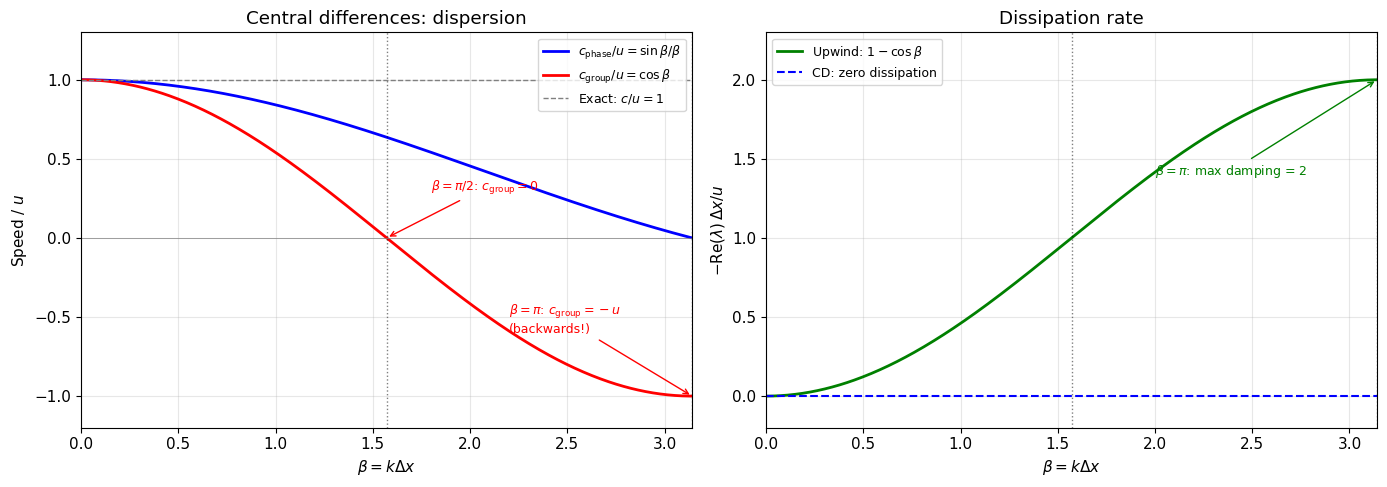

In [19]:
# ── Problem 2(b): Phase speed, group velocity, dissipation plots ──
beta = np.linspace(1e-6, np.pi, 500)

c_phase_CD = np.sin(beta) / beta        # c_phase / u
c_group_CD = np.cos(beta)               # c_group / u
dissipation_UW = 1 - np.cos(beta)       # -Re(lambda_UW)*dx/u

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: phase speed and group velocity
ax1.plot(beta, c_phase_CD, 'b-', lw=2, label=r'$c_{\rm phase}/u = \sin\beta/\beta$')
ax1.plot(beta, c_group_CD, 'r-', lw=2, label=r'$c_{\rm group}/u = \cos\beta$')
ax1.axhline(1, color='gray', ls='--', lw=1, label=r'Exact: $c/u = 1$')
ax1.axhline(0, color='gray', ls='-', lw=0.5)
ax1.axvline(np.pi/2, color='k', ls=':', lw=1, alpha=0.5)
ax1.axvline(np.pi,   color='k', ls=':', lw=1, alpha=0.5)
ax1.annotate(r'$\beta=\pi/2$: $c_{\rm group}=0$', xy=(np.pi/2, 0), xytext=(1.8, 0.3),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax1.annotate(r'$\beta=\pi$: $c_{\rm group}=-u$'+'\n(backwards!)', xy=(np.pi, -1), xytext=(2.2, -0.6),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='red'), color='red')
ax1.set_xlabel(r'$\beta = k\Delta x$');  ax1.set_ylabel('Speed / $u$')
ax1.set_title('Central differences: dispersion');  ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(0, np.pi);  ax1.set_ylim(-1.2, 1.3);  ax1.grid(True, alpha=0.3)

# Right: dissipation
ax2.plot(beta, dissipation_UW, 'g-', lw=2, label=r'Upwind: $1 - \cos\beta$')
ax2.axhline(0, color='b', ls='--', lw=1.5, label='CD: zero dissipation')
ax2.axvline(np.pi/2, color='k', ls=':', lw=1, alpha=0.5)
ax2.axvline(np.pi,   color='k', ls=':', lw=1, alpha=0.5)
ax2.annotate(r'$\beta=\pi$: max damping = 2', xy=(np.pi, 2), xytext=(2.0, 1.4),
             fontsize=9, arrowprops=dict(arrowstyle='->', color='green'), color='green')
ax2.set_xlabel(r'$\beta = k\Delta x$');  ax2.set_ylabel(r'$-\mathrm{Re}(\lambda)\,\Delta x / u$')
ax2.set_title('Dissipation rate');  ax2.legend(fontsize=9);  ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, np.pi);  ax2.set_ylim(-0.2, 2.3)

plt.tight_layout();  plt.show()

**Observations.** CD is purely dispersive ($\text{Re}(\lambda)=0$): phase speed $\sin\beta/\beta < 1$ (lagging), group velocity $\cos\beta$ reverses sign for $\beta > \pi/2$. Upwind has the same dispersion relation but adds dissipation $1-\cos\beta$, which preferentially kills short waves whose group velocity is reversed. Trade-off: CD preserves amplitude but sends grid-scale energy backwards; upwind corrects the direction but destroys it.

**2c)** Wave packet demonstration (10 pts)

The group velocity governs how the *envelope* of a wave packet propagates — often more physically relevant than the phase speed. Demonstrate this numerically.

Initialize a Gaussian-modulated wave packet on $[-8, 8]$ with $N = 320$ points, $u = 1$:
$$U_0(x) = e^{-x^2/\sigma^2}\cos(k_0 x), \qquad \sigma = 2.0, \quad \beta_0 = k_0\Delta x = \frac{\pi}{4}.$$

1. **Predict** analytically: at what speed should the packet envelope travel according to $c_{\text{group}}^{\text{CD}}(\pi/4)$? How far should it travel by $t = 5$? Compare to where the exact convection equation would put it.

2. **Simulate** to $t = 5$ using the central difference semi-discrete operator with **RK4** time integration (CFL $= 0.5$, periodic BCs). Plot the initial and final solutions on the same axes.

3. **Track** the envelope peak $x_{\text{peak}}(t)$ at saved timesteps (every 50 steps). Estimate the numerical group speed from $x_{\text{peak}}(t)/t$ and compare to the analytical prediction $c_{\text{group}} = u\cos(\pi/4) = u/\sqrt{2}$.

4. **Repeat** with the upwind scheme (using Forward Euler, same CFL). How does the wave packet differ? Can you still track the envelope peak? Explain in terms of the dissipation rate at $\beta_0 = \pi/4$.

### Solution Problem 2(c)

**Analytical prediction.** With $\beta_0 = \pi/4$: $c_{\text{group}} = u\cos(\pi/4) = u/\sqrt{2} \approx 0.707u$. By $t=5$ the envelope should be at $x = 5/\sqrt{2} \approx 3.54$, while exact advection gives $x = 5$. The envelope **lags** by $\approx 1.46$.

**Upwind prediction.** Dissipation per cell: $1 - \cos(\pi/4) \approx 0.293$. Over $\sim 100$ cells the amplitude decays by $e^{-29} \approx 10^{-13}$ — the packet is obliterated.

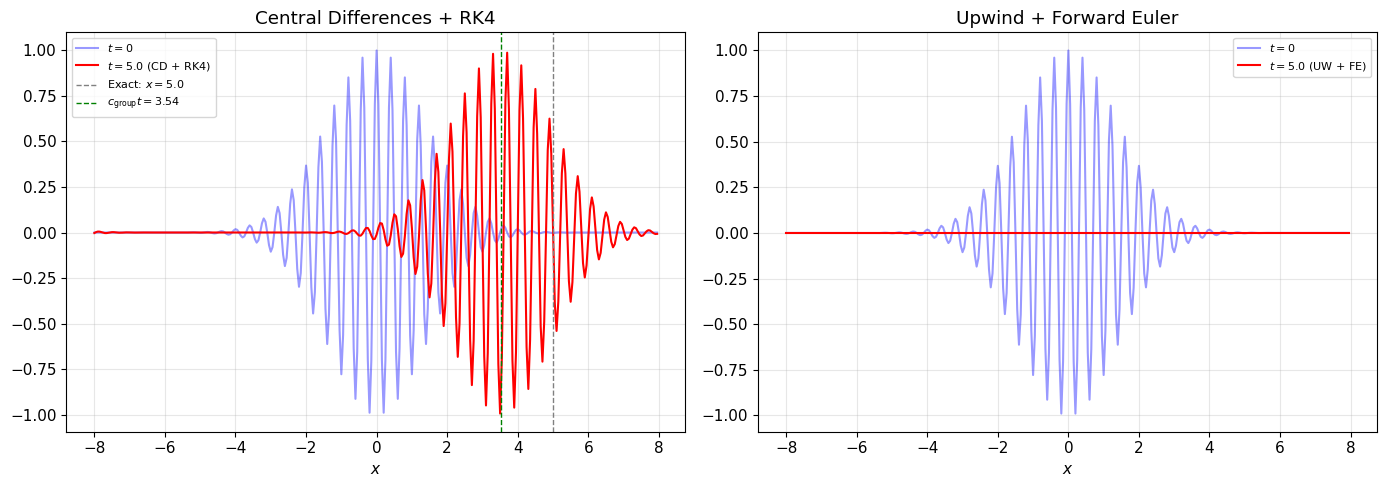

Analytical c_group = u·cos(π/4) = 0.707107
Numerical  c_group (linear fit) = 0.680000
Relative error: 3.83e-02

At t = 5.0:
  Predicted envelope position: 3.536
  Exact advection position:    5.000
  Envelope lag: 1.464


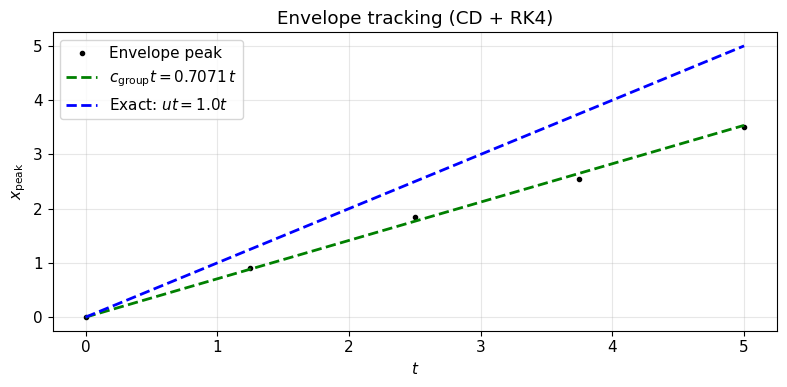


Upwind + FE: max|U| at t=5.0: 3.48e-07 (packet obliterated by dissipation)


In [ ]:
# ── Problem 2(c): Wave packet demonstration ──

# Setup
L, N = 16.0, 320
dx = L / N
x = np.linspace(-L/2, L/2 - dx, N)
u_speed = 1.0
CFL = 0.5
dt = CFL * dx / u_speed
sigma = 2.0
beta0 = np.pi / 4
k0 = beta0 / dx

# Initial condition
U0 = np.exp(-x**2 / sigma**2) * np.cos(k0 * x)

# ── Semi-discrete operators ──
def rhs_CD(U):
    """Central difference: du/dt = -u * (U_{j+1} - U_{j-1}) / (2*dx)"""
    return -u_speed * (np.roll(U, -1) - np.roll(U, 1)) / (2 * dx)

def rhs_UW(U):
    """Upwind: du/dt = -u * (U_j - U_{j-1}) / dx"""
    return -u_speed * (U - np.roll(U, 1)) / dx

# ── Time integrators ──
def step_RK4(U, rhs, dt):
    k1 = rhs(U)
    k2 = rhs(U + 0.5*dt*k1)
    k3 = rhs(U + 0.5*dt*k2)
    k4 = rhs(U + dt*k3)
    return U + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

def step_FE(U, rhs, dt):
    return U + dt * rhs(U)

# ── Run simulation ──
T_final = 5.0
n_steps = int(round(T_final / dt))
save_every = 50

def run_sim(U0, step_fn, rhs_fn, dt, n_steps, save_every):
    U = U0.copy()
    times, peaks = [0.0], [x[np.argmax(np.abs(U))]]
    for n in range(1, n_steps + 1):
        U = step_fn(U, rhs_fn, dt)
        if n % save_every == 0 or n == n_steps:
            # Track peak of envelope (absolute value)
            peaks.append(x[np.argmax(np.abs(U))])
            times.append(n * dt)
    return U, np.array(times), np.array(peaks)

U_cd, t_cd, peaks_cd = run_sim(U0, step_RK4, rhs_CD, dt, n_steps, save_every)
U_uw, t_uw, peaks_uw = run_sim(U0, step_FE, rhs_UW, dt, n_steps, save_every)

# ── Part 2: Plot initial and final solutions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CD + RK4
axes[0].plot(x, U0, 'b-', alpha=0.4, label='$t = 0$')
axes[0].plot(x, U_cd, 'r-', lw=1.5, label=f'$t = {T_final}$ (CD + RK4)')
x_exact = 0 + u_speed * T_final   # exact peak position (mod periodicity)
x_group = 0 + u_speed * np.cos(beta0) * T_final
axes[0].axvline(np.mod(x_exact + L/2, L) - L/2, color='gray', ls='--', lw=1, label=f'Exact: $x = {x_exact:.1f}$')
axes[0].axvline(np.mod(x_group + L/2, L) - L/2, color='green', ls='--', lw=1, label=f'$c_{{\\rm group}}t = {x_group:.2f}$')
axes[0].set_title('Central Differences + RK4');  axes[0].legend(fontsize=8)
axes[0].set_xlabel('$x$');  axes[0].grid(True, alpha=0.3)

# Upwind + FE
axes[1].plot(x, U0, 'b-', alpha=0.4, label='$t = 0$')
axes[1].plot(x, U_uw, 'r-', lw=1.5, label=f'$t = {T_final}$ (UW + FE)')
axes[1].set_title('Upwind + Forward Euler');  axes[1].legend(fontsize=8)
axes[1].set_xlabel('$x$');  axes[1].grid(True, alpha=0.3)

plt.tight_layout();  plt.show()

# ── Part 3: Group speed from peak tracking ──
# Only meaningful for CD (upwind kills the packet)
mask = t_cd > 0.5  # skip early transient
if np.sum(mask) > 1:
    # Unwrap peaks for periodic domain
    peaks_unwrapped = np.unwrap(peaks_cd * 2 * np.pi / L) * L / (2 * np.pi)
    slope, intercept = np.polyfit(t_cd[mask], peaks_unwrapped[mask], 1)
    c_group_exact = u_speed * np.cos(beta0)
    
    print(f"Analytical c_group = u·cos(π/4) = {c_group_exact:.6f}")
    print(f"Numerical  c_group (linear fit) = {slope:.6f}")
    print(f"Relative error: {abs(slope - c_group_exact)/c_group_exact:.2e}")
    print(f"\nAt t = {T_final}:")
    print(f"  Predicted envelope position: {c_group_exact * T_final:.3f}")
    print(f"  Exact advection position:    {u_speed * T_final:.3f}")
    print(f"  Envelope lag: {(u_speed - c_group_exact) * T_final:.3f}")
    
    fig2, ax = plt.subplots(figsize=(8, 4))
    ax.plot(t_cd, peaks_unwrapped, 'ko', ms=3, label='Envelope peak')
    ax.plot(t_cd, c_group_exact * t_cd, 'g--', lw=2, 
            label=rf'$c_{{\rm group}} t = {c_group_exact:.4f}\,t$')
    ax.plot(t_cd, u_speed * t_cd, 'b--', lw=2, label=f'Exact: $u t = {u_speed}t$')
    ax.set_xlabel('$t$');  ax.set_ylabel('$x_{\\rm peak}$')
    ax.set_title('Envelope tracking (CD + RK4)');  ax.legend();  ax.grid(True, alpha=0.3)
    plt.tight_layout();  plt.show()

print(f"\nUpwind + FE: max|U| at t={T_final}: {np.max(np.abs(U_uw)):.2e}"
      f" (packet obliterated by dissipation)")

**Results.** CD + RK4 confirms the group-velocity prediction: the envelope travels at $c_{\text{group}} \approx u/\sqrt{2}$, not $u$. Upwind + FE kills the packet entirely — dissipation at $\beta_0 = \pi/4$ is too strong to preserve any amplitude over this distance.